## LUCiO Colab instructions

This notebook generates Lucia/RX1-compatible `.lscf` sourcecode files from audio. It uses a validated GUI-authored dynamic-duty template:

```text
d_spcwkdc1020904022_various.lscf
```

Upload this template first, then upload one or more audio files. The notebook will generate:

```text
user/sourcecodes/d_<audio_name>_various.lscf
debug/<audio_name>_lucio_debug.csv
plots/<audio_name>_lucio_sequence_plot.png
plots/<audio_name>_lucio_sequence_plot.pdf
```

Copy one generated `.lscf` at a time into:

```text
USB Lucia/user/sourcecodes/
```

Then load it in Lucia via:

```text
Session editor → D → various → spcwkdc1020904022
```

The generated file will initially appear under the template’s internal Lucia name, `spcwkdc1020904022`. This is expected because LUCIO-D preserves the validated dynamic-duty template header. After loading, save/resave the file in Lucia as a normal session or session configuration with the desired final name.

Current validated features: dynamic frequency, dynamic luminance, dynamic duty cycle, all-four-oscillator output, 1-s row-based control, playable/resavable Lucia sourcecodes. Current limitations: inherited internal display name, one-file-at-a-time loading recommended, no halogen/wash-light layer yet.


LUCIO-D sourcecode export

Step 1: upload the validated dynamic-duty Lucia template:
  d_spcwkdc1020904022_various.lscf



Saving d_spcwkdc1020904022_various.lscf to d_spcwkdc1020904022_various (3).lscf
Template loaded
  File: d_spcwkdc1020904022_various (3).lscf
  Lucia display name: spcwkdc1020904022
  Template rows: 461
  First-row OSC duties: [10, 10, 10, 10]

Step 2: upload one or more audio files
Supported: wav, mp3, flac, m4a, ogg, aiff



Saving DJS_space_walk.mp3 to DJS_space_walk (1).mp3
------------------------------------------------------------
Processing: DJS_space_walk (1).mp3
  Duration: 460.30 s
  Output file: d_djsspacewalk1_various.lscf
  Lucia display name: spcwkdc1020904022
  Control step: 1.00 s


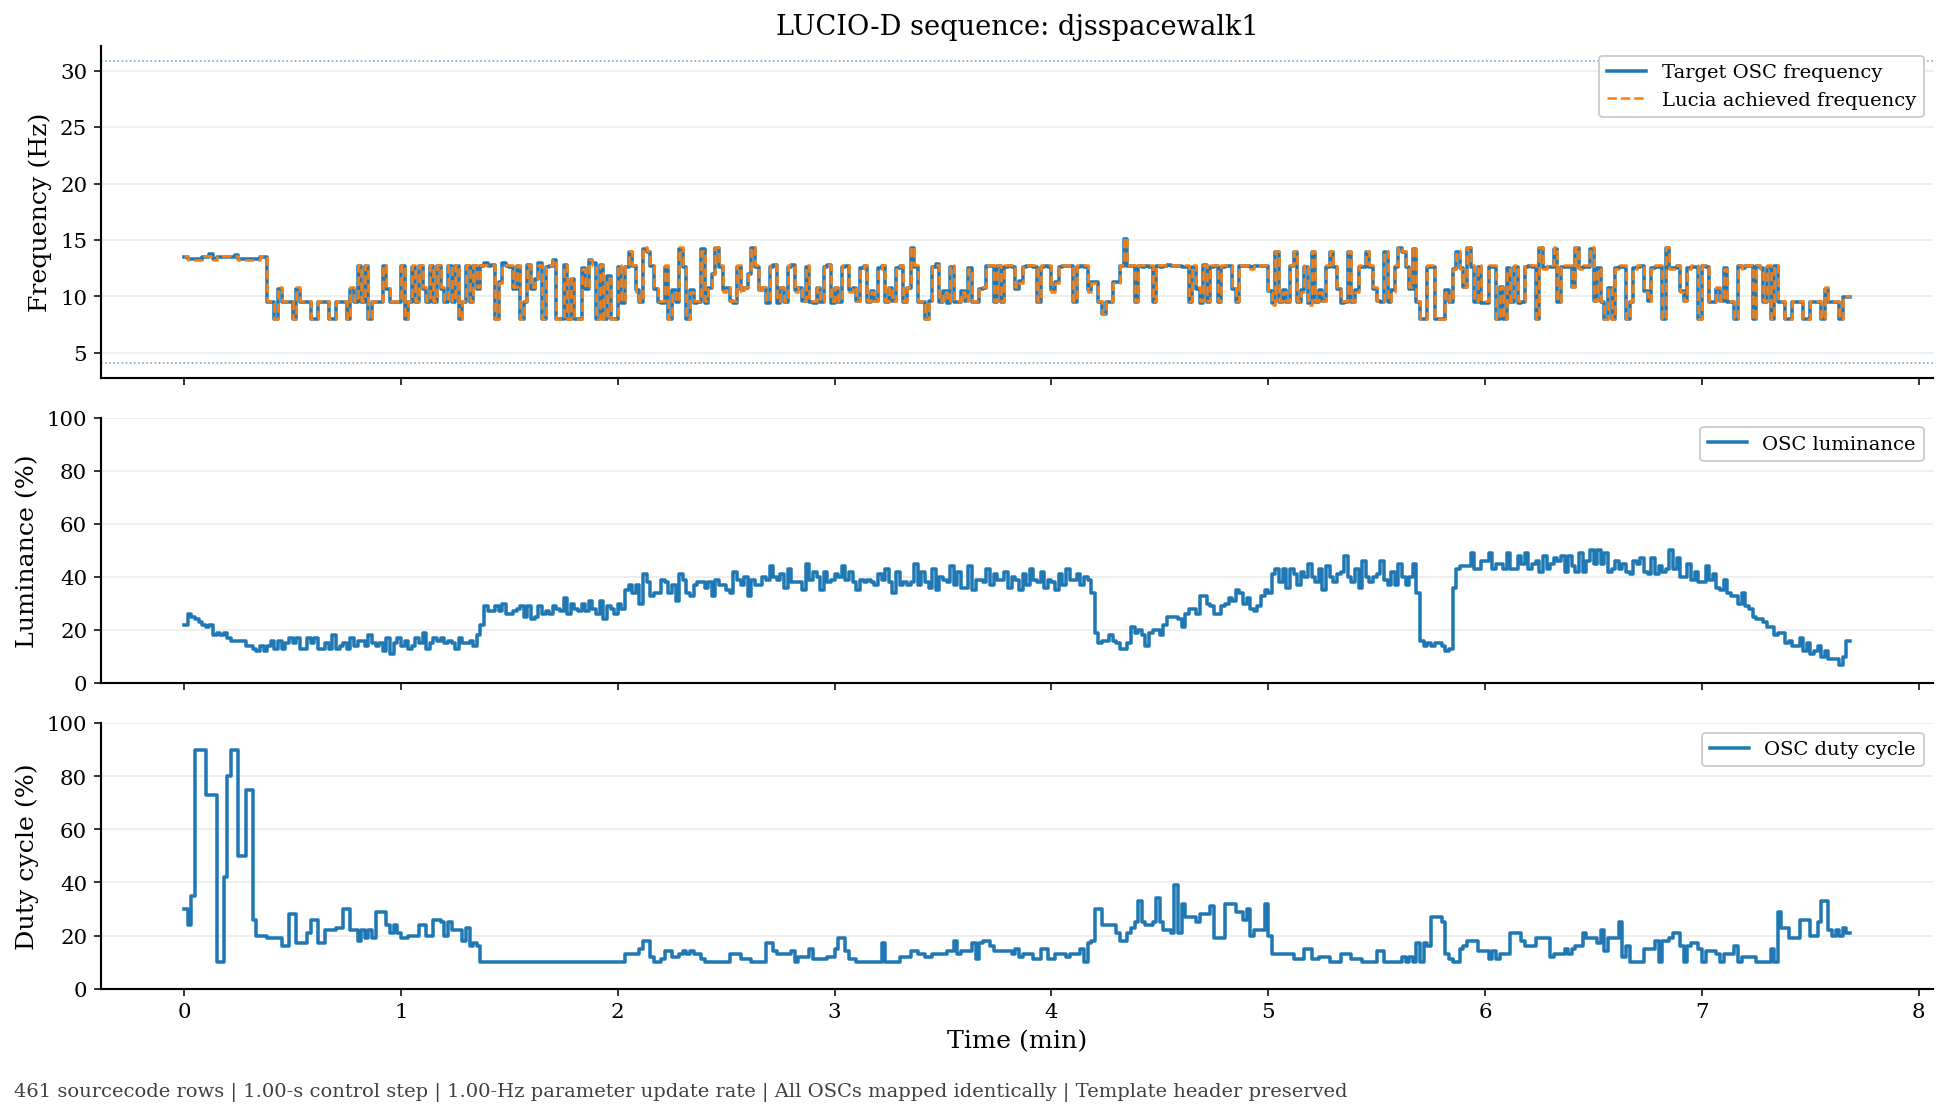

  Rows written: 461
  Approx duration: 461.00 s
  Achieved frequency: 8.00–15.20 Hz
  Luminance: 7–50
  Duty cycle: 10–90
  Checksum valid: True

LUCIO-D export complete
Copy one generated .lscf file at a time into:
  USB Lucia/user/sourcecodes/

Then load in Lucia:
  Session editor -> D -> various -> spcwkdc1020904022

The output filename is audio-specific, but the initial Lucia display
name is inherited from the validated template. After loading, resave
the sourcecode/session in Lucia under the desired final name.

Export settings:
  Control step: 1.00 s
  Parameter update rate: 1.00 Hz
  Duty method: occupancy
  Duty bounds: 10–90
  Luminance bounds: 5–50


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ============================================================
# LUCiO
# Lucia Unified Control Interface for OctAVEs
# Dynamic-duty sourcecode export for Lucia/RX1
# ============================================================
#
# Purpose
# -------
# Converts an audio file into a Lucia/RX1-compatible .lscf sourcecode.
# The generated sourcecode contains one row per control window and maps
# audio-derived features to:
#
#   - oscillator frequency
#   - oscillator luminance
#   - oscillator duty cycle
#
# Validated template
# ------------------
# Use the GUI-authored dynamic-duty template:
#
#   d_spcwkdc1020904022_various.lscf
#
# This template's header/internal identity is preserved. Therefore, inside
# Lucia, generated sourcecodes will initially appear under the template's
# internal display name:
#
#   spcwkdc1020904022
#
# After loading in Lucia, the sourcecode can be saved/resaved as a normal
# session or session configuration with the desired final name.
#
# Output
# ------
#   user/sourcecodes/d_<audio_name>_various.lscf
#   debug/<audio_name>_lucio_debug.csv
#   plots/<audio_name>_lucio_sequence_plot.png
#   plots/<audio_name>_lucio_sequence_plot.pdf
#
# Recommended use
# ---------------
# Copy one generated .lscf at a time into:
#
#   USB Lucia/user/sourcecodes/
#
# Then load in Lucia:
#
#   Session editor -> D -> various -> spcwkdc1020904022
#
# ============================================================

!pip -q install librosa soundfile numpy pandas scipy matplotlib

from __future__ import annotations

import math
import re
import struct
import zipfile
from dataclasses import dataclass
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import hilbert

from google.colab import files


# ============================================================
# CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class LucioConfig:
    # Row/control timing
    control_step_seconds: float = 1.0
    displayed_seconds_tenths: int = 10
    loops_per_row: int = 1

    # Luminance mapping
    luminance_min: int = 5
    luminance_max: int = 50

    # Duty-cycle mapping: "occupancy", "mean_envelope", or "fixed"
    duty_method: str = "occupancy"
    duty_fixed: int = 50
    duty_min: int = 10
    duty_max: int = 90
    duty_fallback: int = 50
    duty_invert: bool = False
    duty_occupancy_threshold: float = 0.35

    # Optional duty shaping
    duty_smooth_rows: int | None = 3
    duty_quantize_step: int | None = 1
    duty_max_row_change: int | None = None

    # Audio spectral extraction
    audio_band_low_hz: float = 40.0
    audio_band_high_hz: float = 6000.0

    # SLS frequency range
    sls_min_hz: float = 4.12
    sls_max_hz: float = 30.87
    sls_center_hz: float = 11.56

    # Plotting
    make_sequence_plot: bool = True
    time_units: str = "min"


CFG = LucioConfig()


# ============================================================
# LUCIA/RX1 BINARY CONSTANTS
# ============================================================

HEADER_LEN = 132
ROW_LEN = 56
CHECKSUM_LEN = 1

NAME_FIELD_OFFSET = 24
NAME_FIELD_LEN = 56

DUTY_OFFSETS = [3, 11, 19, 27]


# ============================================================
# LOW-LEVEL LUCIA HELPERS
# ============================================================

def lucia_xor_checksum(data_without_checksum: bytes) -> int:
    checksum = 0
    for byte in data_without_checksum:
        checksum ^= byte
    return checksum


def finalize_lucia_file(buffer: bytearray) -> bytearray:
    buffer = bytearray(buffer)
    buffer[-1] = lucia_xor_checksum(buffer[:-1])
    return buffer


def verify_lucia_checksum(data: bytes) -> bool:
    return data[-1] == lucia_xor_checksum(data[:-1])


def read_internal_name(data: bytes) -> str:
    raw = bytes(data[NAME_FIELD_OFFSET:NAME_FIELD_OFFSET + NAME_FIELD_LEN])
    raw = raw.split(b"\x00", 1)[0]
    return raw.decode("ascii", errors="replace")


def sanitize_filename_stem(name: str, max_len: int = 18) -> str:
    stem = Path(str(name)).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "", stem)

    if not stem:
        stem = "lucio"

    if stem[0].isdigit():
        stem = "l" + stem

    return stem[:max_len]


def parse_lucia_rows(data: bytes) -> list[bytearray]:
    n_rows = (len(data) - HEADER_LEN - CHECKSUM_LEN) // ROW_LEN
    expected_len = HEADER_LEN + n_rows * ROW_LEN + CHECKSUM_LEN

    if len(data) != expected_len:
        raise ValueError(
            f"Invalid .lscf size: {len(data)} bytes. "
            f"Expected 132 + 56*N + 1 bytes."
        )

    return [
        bytearray(data[HEADER_LEN + i * ROW_LEN:HEADER_LEN + (i + 1) * ROW_LEN])
        for i in range(n_rows)
    ]


def main_cycle_seconds_from_row(row: bytes) -> float:
    stored = struct.unpack("<H", bytes(row[44:46]))[0]
    if stored <= 0:
        return 2.5
    return 2500.0 / float(stored)


def clamp_byte(value: float) -> int:
    return int(np.clip(round(float(value)), 0, 255))


def cycles_from_hz(freq_hz: float, main_cycle_seconds: float) -> int:
    cycles = int(round(float(freq_hz) * float(main_cycle_seconds)))
    return int(np.clip(cycles, 1, 255))


# ============================================================
# AUDIO FEATURE EXTRACTION
# ============================================================

def octave_candidates(freq_hz: float, max_pow: int = 14) -> list[float]:
    if freq_hz <= 0:
        return []
    return [float(freq_hz) * (2.0 ** k) for k in range(-max_pow, max_pow + 1)]


def fold_frequency_to_sls_range(freq_hz: float, cfg: LucioConfig = CFG) -> float:
    if freq_hz <= 0:
        return cfg.sls_center_hz

    candidates = [
        f for f in octave_candidates(freq_hz)
        if cfg.sls_min_hz <= f <= cfg.sls_max_hz
    ]

    if candidates:
        candidates.sort(key=lambda f: abs(f - cfg.sls_center_hz))
        return float(candidates[0])

    folded = float(freq_hz)

    for _ in range(64):
        if folded < cfg.sls_min_hz:
            folded *= 2.0
        elif folded > cfg.sls_max_hz:
            folded /= 2.0
        else:
            break

    return float(np.clip(folded, cfg.sls_min_hz, cfg.sls_max_hz))


def next_power_of_two(n: int) -> int:
    return 1 << (int(n) - 1).bit_length()


def dominant_frequency_for_segment(
    segment: np.ndarray,
    sr: int,
    cfg: LucioConfig = CFG
) -> float:
    segment = np.asarray(segment, dtype=np.float32)

    if len(segment) < 16 or np.max(np.abs(segment)) <= 0:
        return cfg.sls_center_hz

    window = np.hanning(len(segment)).astype(np.float32)
    n_fft = max(4096, next_power_of_two(len(segment)))

    spectrum = np.abs(np.fft.rfft(segment * window, n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sr)

    band = (freqs >= cfg.audio_band_low_hz) & (freqs <= cfg.audio_band_high_hz)

    if not np.any(band):
        return cfg.sls_center_hz

    band_spectrum = spectrum[band]
    band_freqs = freqs[band]

    if len(band_spectrum) == 0 or np.max(band_spectrum) <= 0:
        return cfg.sls_center_hz

    return float(band_freqs[int(np.argmax(band_spectrum))])


def raw_duty_for_segment(segment: np.ndarray, cfg: LucioConfig = CFG) -> float:
    method = cfg.duty_method.lower().strip()

    if method == "fixed":
        return float(cfg.duty_fixed)

    segment = np.asarray(segment, dtype=np.float32)

    if len(segment) < 16 or np.max(np.abs(segment)) <= 0:
        return float(cfg.duty_fallback)

    envelope = np.abs(hilbert(segment.astype(np.float64)))
    peak = float(np.max(envelope))

    if peak <= 1e-12:
        return float(cfg.duty_fallback)

    envelope_norm = envelope / peak

    if method == "occupancy":
        duty = 100.0 * float(np.mean(envelope_norm > cfg.duty_occupancy_threshold))
    elif method == "mean_envelope":
        duty = 100.0 * float(np.mean(envelope_norm))
    else:
        raise ValueError(
            f"Unknown duty method: {cfg.duty_method}. "
            "Use 'occupancy', 'mean_envelope', or 'fixed'."
        )

    if cfg.duty_invert:
        duty = 100.0 - duty

    return float(duty)


def shape_duty_series(
    duty_values: np.ndarray,
    cfg: LucioConfig = CFG
) -> np.ndarray:
    duty = pd.Series(np.asarray(duty_values, dtype=float))
    duty = duty.clip(cfg.duty_min, cfg.duty_max)

    if cfg.duty_smooth_rows is not None and cfg.duty_smooth_rows > 1:
        duty = duty.rolling(
            window=int(cfg.duty_smooth_rows),
            center=True,
            min_periods=1
        ).median()

    duty_array = duty.to_numpy(dtype=float)

    if cfg.duty_max_row_change is not None and cfg.duty_max_row_change > 0:
        shaped = np.zeros_like(duty_array)
        shaped[0] = duty_array[0]

        for i in range(1, len(duty_array)):
            delta = duty_array[i] - shaped[i - 1]
            delta = np.clip(delta, -cfg.duty_max_row_change, cfg.duty_max_row_change)
            shaped[i] = shaped[i - 1] + delta

        duty_array = shaped

    if cfg.duty_quantize_step is not None and cfg.duty_quantize_step > 0:
        duty_array = np.round(duty_array / cfg.duty_quantize_step) * cfg.duty_quantize_step

    duty_array = np.clip(
        np.round(duty_array),
        cfg.duty_min,
        cfg.duty_max
    ).astype(int)

    return duty_array


def extract_audio_control_table(
    audio_path: str,
    cfg: LucioConfig = CFG
) -> pd.DataFrame:
    y, sr = librosa.load(audio_path, sr=None, mono=True)
    y = y.astype(np.float32)

    step_samples = int(round(sr * cfg.control_step_seconds))

    if step_samples <= 0:
        raise ValueError("control_step_seconds must be positive.")

    n_steps = int(math.ceil(len(y) / step_samples))
    rows = []

    for i in range(n_steps):
        start = i * step_samples
        stop = min(len(y), start + step_samples)
        segment = y[start:stop]

        if len(segment) == 0:
            continue

        raw_freq = dominant_frequency_for_segment(segment, sr, cfg)
        sls_freq = fold_frequency_to_sls_range(raw_freq, cfg)

        rms = float(np.sqrt(np.mean(segment ** 2))) if len(segment) else 0.0
        duty_raw = raw_duty_for_segment(segment, cfg)

        rows.append({
            "row": i + 1,
            "time_sec": i * cfg.control_step_seconds,
            "raw_freq_hz": raw_freq,
            "sls_freq_hz": sls_freq,
            "rms": rms,
            "duty_raw": duty_raw
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No control rows extracted from {audio_path}")

    rms_max = float(df["rms"].max())
    if rms_max <= 0:
        rms_max = 1.0

    df["amp_norm"] = df["rms"] / rms_max
    df["luminance"] = (
        cfg.luminance_min
        + df["amp_norm"] * (cfg.luminance_max - cfg.luminance_min)
    ).round().clip(cfg.luminance_min, cfg.luminance_max).astype(int)

    df["duty"] = shape_duty_series(df["duty_raw"].values, cfg)

    return df


# ============================================================
# LUCIA ROW GENERATION
# ============================================================

def patch_lucia_row(
    template_row: bytes,
    control_row: pd.Series,
    cfg: LucioConfig = CFG
) -> tuple[bytearray, dict]:
    row = bytearray(template_row)

    main_cycle_seconds = main_cycle_seconds_from_row(row)

    freq_hz = float(control_row["sls_freq_hz"])
    luminance = int(control_row["luminance"])
    duty = int(control_row["duty"])
    cycles = cycles_from_hz(freq_hz, main_cycle_seconds)

    for osc in range(4):
        base = osc * 8

        row[base + 0] = 1
        row[base + 1] = 1
        row[base + 2] = 100
        row[base + 3] = clamp_byte(duty)
        row[base + 4] = clamp_byte(cycles)
        row[base + 5] = 0
        row[base + 6] = 1
        row[base + 7] = 0

    for osc in range(4):
        row[32 + osc] = clamp_byte(luminance)
        row[36 + osc] = 1

    # Validated D/various halogen-off grammar.
    row[40:44] = bytes([0x00, 0x01, 0x00, 0x14])

    # Sourcecode row timing/control convention.
    row[46] = 1
    row[47] = 1
    row[48] = clamp_byte(cfg.displayed_seconds_tenths)
    row[49] = 0
    row[50] = 0
    row[51] = 0

    row[52:56] = struct.pack("<I", int(cfg.loops_per_row))

    debug = {
        "main_cycle_seconds": main_cycle_seconds,
        "displayed_row_seconds": row[48] / 10.0,
        "cycles": cycles,
        "achieved_freq_hz": cycles / main_cycle_seconds,
        "row_40_56_hex": row[40:56].hex(" ")
    }

    return row, debug


def build_lucia_sourcecode(
    template_data: bytes,
    control_df: pd.DataFrame,
    output_path: str,
    cfg: LucioConfig = CFG
) -> tuple[str, pd.DataFrame]:
    template_data = bytearray(template_data)
    template_rows = parse_lucia_rows(template_data)
    template_row = template_rows[0]

    out = bytearray()
    out.extend(template_data[:HEADER_LEN])

    debug_rows = []

    for _, control_row in control_df.iterrows():
        patched_row, row_debug = patch_lucia_row(template_row, control_row, cfg)
        out.extend(patched_row)

        debug_row = dict(control_row)
        debug_row.update(row_debug)
        debug_rows.append(debug_row)

    out.extend(b"\x00")
    out = finalize_lucia_file(out)

    if not verify_lucia_checksum(out):
        raise RuntimeError("Final Lucia XOR checksum failed.")

    Path(output_path).write_bytes(out)

    return output_path, pd.DataFrame(debug_rows)


# ============================================================
# SEQUENCE PLOT
# ============================================================

def make_sequence_plot(
    debug_df: pd.DataFrame,
    stem: str,
    cfg: LucioConfig = CFG
) -> tuple[str, str]:
    time_sec = debug_df["time_sec"].to_numpy(dtype=float)

    if cfg.time_units.lower().startswith("min"):
        t = time_sec / 60.0
        final_t = (time_sec[-1] + cfg.control_step_seconds) / 60.0
        x_label = "Time (min)"
    else:
        t = time_sec
        final_t = time_sec[-1] + cfg.control_step_seconds
        x_label = "Time (s)"

    t_step = np.append(t, final_t)

    def step_values(values):
        values = np.asarray(values, dtype=float)
        return np.append(values, values[-1])

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Palatino", "Palatino Linotype", "DejaVu Serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.1,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.dpi": 140,
    })

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0]}
    )

    ax_freq, ax_lum, ax_duty = axes

    ax_freq.step(
        t_step,
        step_values(debug_df["sls_freq_hz"]),
        where="post",
        linewidth=1.8,
        label="Target OSC frequency"
    )
    ax_freq.step(
        t_step,
        step_values(debug_df["achieved_freq_hz"]),
        where="post",
        linewidth=1.3,
        linestyle="--",
        label="Lucia achieved frequency"
    )
    ax_freq.axhline(cfg.sls_min_hz, linewidth=0.8, linestyle=":", alpha=0.7)
    ax_freq.axhline(cfg.sls_max_hz, linewidth=0.8, linestyle=":", alpha=0.7)
    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"LUCIO-D sequence: {stem}")
    ax_freq.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_freq.grid(axis="y", alpha=0.25)

    ax_lum.step(
        t_step,
        step_values(debug_df["luminance"]),
        where="post",
        linewidth=1.8,
        label="OSC luminance"
    )
    ax_lum.set_ylabel("Luminance (%)")
    ax_lum.set_ylim(0, max(100, float(debug_df["luminance"].max()) * 1.1))
    ax_lum.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_lum.grid(axis="y", alpha=0.25)

    ax_duty.step(
        t_step,
        step_values(debug_df["duty"]),
        where="post",
        linewidth=1.8,
        label="OSC duty cycle"
    )
    ax_duty.set_ylabel("Duty cycle (%)")
    ax_duty.set_ylim(0, 100)
    ax_duty.set_xlabel(x_label)
    ax_duty.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_duty.grid(axis="y", alpha=0.25)

    footer = (
        f"{len(debug_df)} sourcecode rows | "
        f"{cfg.control_step_seconds:.2f}-s control step | "
        f"{1 / cfg.control_step_seconds:.2f}-Hz parameter update rate | "
        "All OSCs mapped identically | "
        "Template header preserved"
    )

    fig.text(0.01, 0.01, footer, ha="left", va="bottom", fontsize=10, alpha=0.75)
    plt.tight_layout(rect=[0, 0.035, 1, 1])

    png_path = f"/content/{stem}_lucio_sequence_plot.png"
    pdf_path = f"/content/{stem}_lucio_sequence_plot.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return png_path, pdf_path


# ============================================================
# COLAB RUNNER
# ============================================================

print("LUCIO-D sourcecode export")
print("")
print("Step 1: upload the validated dynamic-duty Lucia template:")
print("  d_spcwkdc1020904022_various.lscf")
print("")

template_upload = files.upload()

template_filename = next(iter(template_upload.keys()))
template_data = bytearray(Path(template_filename).read_bytes())
template_rows = parse_lucia_rows(template_data)

if not verify_lucia_checksum(template_data):
    raise RuntimeError("Template checksum is invalid.")

template_display_name = read_internal_name(template_data)

print("Template loaded")
print(f"  File: {template_filename}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Template rows: {len(template_rows)}")
print(f"  First-row OSC duties: {[template_rows[0][off] for off in DUTY_OFFSETS]}")
print("")

print("Step 2: upload one or more audio files")
print("Supported: wav, mp3, flac, m4a, ogg, aiff")
print("")

audio_upload = files.upload()

audio_exts = {".wav", ".mp3", ".flac", ".m4a", ".ogg", ".aiff", ".aif"}
audio_paths = [
    Path(filename)
    for filename in audio_upload.keys()
    if Path(filename).suffix.lower() in audio_exts
]

if not audio_paths:
    raise ValueError("No supported audio files were uploaded.")

outputs = []

for audio_path in audio_paths:
    audio_stem = sanitize_filename_stem(audio_path.stem, max_len=18)

    lscf_path = f"/content/d_{audio_stem}_various.lscf"
    debug_path = f"/content/{audio_stem}_lucio_debug.csv"

    info = sf.info(str(audio_path))
    duration_sec = info.frames / info.samplerate

    print("------------------------------------------------------------")
    print(f"Processing: {audio_path.name}")
    print(f"  Duration: {duration_sec:.2f} s")
    print(f"  Output file: {Path(lscf_path).name}")
    print(f"  Lucia display name: {template_display_name}")
    print(f"  Control step: {CFG.control_step_seconds:.2f} s")

    control_df = extract_audio_control_table(str(audio_path), CFG)

    _, debug_df = build_lucia_sourcecode(
        template_data=template_data,
        control_df=control_df,
        output_path=lscf_path,
        cfg=CFG
    )

    debug_df.to_csv(debug_path, index=False)

    plot_paths = []
    if CFG.make_sequence_plot:
        plot_paths = list(make_sequence_plot(debug_df, audio_stem, CFG))

    print(f"  Rows written: {len(debug_df)}")
    print(f"  Approx duration: {len(debug_df) * CFG.control_step_seconds:.2f} s")
    print(
        f"  Achieved frequency: "
        f"{debug_df['achieved_freq_hz'].min():.2f}–"
        f"{debug_df['achieved_freq_hz'].max():.2f} Hz"
    )
    print(
        f"  Luminance: "
        f"{int(debug_df['luminance'].min())}–"
        f"{int(debug_df['luminance'].max())}"
    )
    print(
        f"  Duty cycle: "
        f"{int(debug_df['duty'].min())}–"
        f"{int(debug_df['duty'].max())}"
    )
    print(f"  Checksum valid: {verify_lucia_checksum(Path(lscf_path).read_bytes())}")
    print("")

    outputs.append((lscf_path, debug_path, plot_paths))

zip_path = "/content/lucio_d_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for lscf_path, debug_path, plot_paths in outputs:
        z.write(lscf_path, arcname=f"user/sourcecodes/{Path(lscf_path).name}")
        z.write(debug_path, arcname=f"debug/{Path(debug_path).name}")

        for plot_path in plot_paths:
            z.write(plot_path, arcname=f"plots/{Path(plot_path).name}")

print("============================================================")
print("LUCIO-D export complete")
print("============================================================")
print("Copy one generated .lscf file at a time into:")
print("  USB Lucia/user/sourcecodes/")
print("")
print("Then load in Lucia:")
print(f"  Session editor -> D -> various -> {template_display_name}")
print("")
print("The output filename is audio-specific, but the initial Lucia display")
print("name is inherited from the validated template. After loading, resave")
print("the sourcecode/session in Lucia under the desired final name.")
print("")
print("Export settings:")
print(f"  Control step: {CFG.control_step_seconds:.2f} s")
print(f"  Parameter update rate: {1 / CFG.control_step_seconds:.2f} Hz")
print(f"  Duty method: {CFG.duty_method}")
print(f"  Duty bounds: {CFG.duty_min}–{CFG.duty_max}")
print(f"  Luminance bounds: {CFG.luminance_min}–{CFG.luminance_max}")
print("============================================================")

files.download(zip_path)